# fig: contrast latency

project = ```iP-VAE```, host = ```mach```, device = ```cuda:0```

**Motivation**: <br>

- Neuron idx: ```order[338]```
- Favorite params: ```{'s_freq': 2.0, 'theta': 48.0}```

Using: (16, 24.0)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.tuning import drifting_grating_feeder, drifting_grating_feeder_params
from utils.animation import show_movie


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Basic setup

In [3]:
pal_models = get_palette_models()

chkpts_dir = add_home('Dropbox/chkpts/_IterativeVAE')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03', 'cntrst')
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(chkpts_dir)), len(os.listdir(figs_dir))

(433, 4)

In [4]:
files = [f for f in os.listdir(chkpts_dir) if 'vH16' in f]
files = sorted(files, key=alphanum_sort_key)

In [5]:
seq_len, beta = 16, 24

selected_fits = [
    f for f in files if (
        f't-{seq_len}_b-{beta:0.3g}' in f
        and 'softplus' not in f)
]
print(selected_fits)

[
    'gaussian+relu-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:45)',
    'gaussian-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,04:09)',
    'poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38)'
]

## Load trainer

In [6]:
f = next(f for f in selected_fits if 'poisson' in f)
tr = load_model_lite(pjoin(chkpts_dir, f), device=device)[0]
u0 = tonp(tr.model.layer.u_init[0].squeeze())
order = np.argsort(u0)

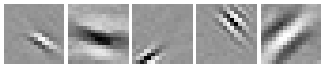

In [7]:
selected_neurons = [380, 47, 281, 117, 338]
tr.model.show(order=order[selected_neurons], method='abs-max', nrows=1, dpi=40);

In [166]:
neuron_i = order[selected_neurons[-1]]
fig, _ = tr.model.show(order=[neuron_i], method='abs-max', nrows=1, dpi=100, display=False)
save_fig(f"proj_field_{neuron_i}.png", save_dir=figs_dir, fig=fig, dpi=600)

neuron_i

318

## Now contrast/latency exploration

### Make feeder

In [9]:
favorite_params = {'s_freq': 2.0, 'theta': 48.0}

In [10]:
param_grid = drifting_grating_feeder_params(
    contrast_min=0.05,
    contrast_max=1.0,
    contrast_delta=0.05,
    theta=[favorite_params['theta']],
    s_freq=[favorite_params['s_freq']],
)

n_frames_for_full_cycle = 500

feeder, feeder_kws = drifting_grating_feeder(
    npix=tr.model.cfg.input_sz[-1],
    param_grid=param_grid,
    device=device,
    n_frames_per_cycle=n_frames_for_full_cycle,
)

### Xtract ftrs

In [53]:
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

n_runs_per_seed = 2
seq = range(n_frames_for_full_cycle * (n_runs_per_seed + 1))

print(seq)

range(0, 1500)

In [13]:
%%time

output = tr.model.xtract_ftr(
    feeder=feeder,
    seq=seq,
    return_extras=['samples', 'u', 'r2'],
).stack()

CPU times: user 6.93 s, sys: 464 ms, total: 7.39 s
Wall time: 27.9 s


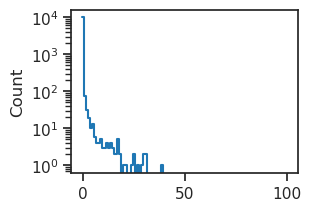

In [14]:
spks = tonp(output['samples'][:, -1].ravel()).astype(int)

fig, ax = create_figure()
histplot(spks, bins=np.linspace(0, 101, 102) - 0.5)
ax.set(yscale='log')
plt.show()

## Get spike trains

In [15]:
neuron_i = order[selected_neurons[-1]]
spike_trains = tonp(output['samples'][..., neuron_i])
spike_trains = spike_trains[:, n_frames_for_full_cycle:]
spike_trains.shape

(20, 1000)

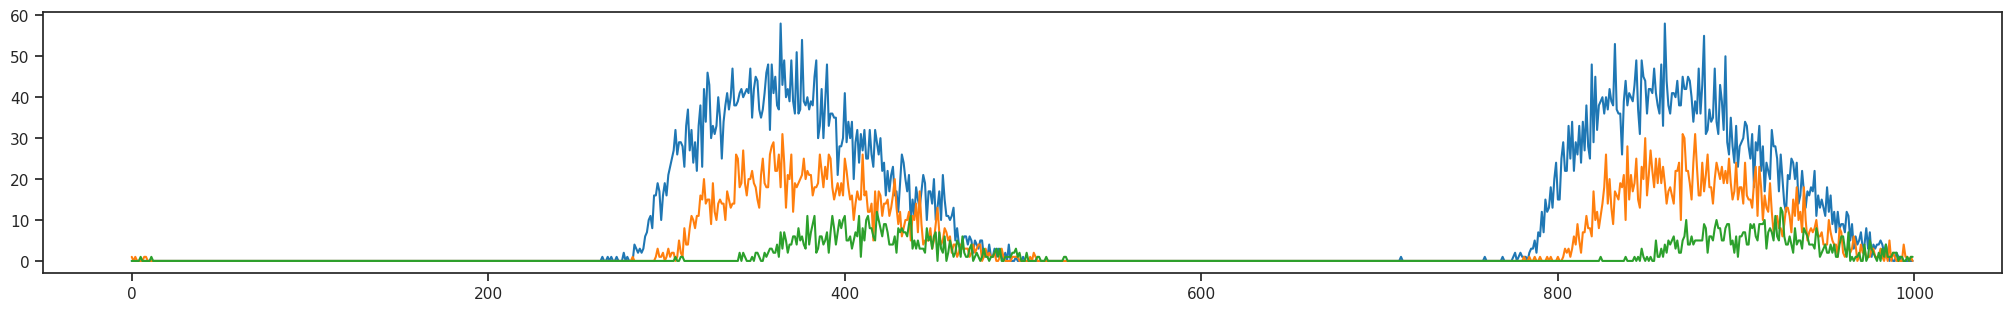

In [19]:
fig, ax = create_figure(1, 1, (20, 3))

ids = [19, 9, 3]
plt.plot(spike_trains[ids].T)
plt.show()

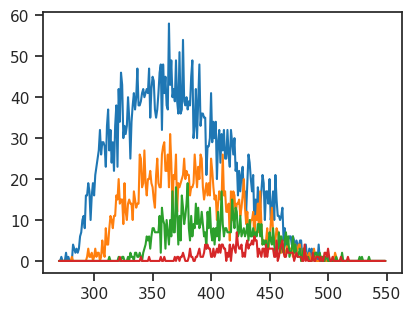

In [23]:
intvl = range(270, 550)

fig, ax = create_figure(1, 1, (4, 3))

ids = [19, 9, 4, 2]
plt.plot(intvl, spike_trains[ids].T[intvl])
plt.show()

In [24]:
param_grid['contrast'][ids]

array([1.  , 0.5 , 0.25, 0.15])

In [25]:
len(param_grid['contrast'])

20

In [26]:
color_spacig = 10
greys = sns.color_palette('Greys', n_colors=len(ids) * color_spacig)

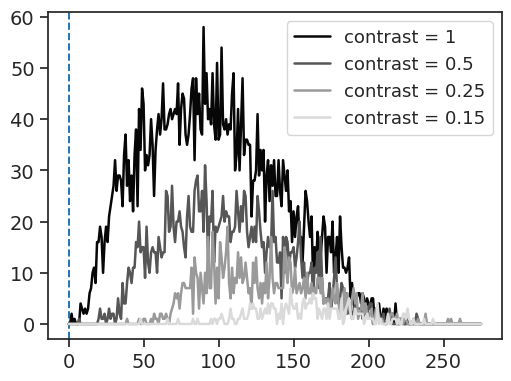

In [28]:
a = 274
b = 550
intvl = range(a, b)

fig, ax = create_figure(1, 1, (5, 3.7))

ids = [19, 9, 4, 2]
for i, idx in enumerate(ids):
    ax.plot(
        range(b - a),
        spike_trains[idx][intvl],
        color=greys[len(greys) - i * color_spacig - 1],
        label=f"contrast = {param_grid['contrast'][idx]:0.2g}",
        lw=1.8,
    )
ax.tick_params(axis='both', labelsize=14)
ax.axvline(0, ls='--', color='C0', lw=1.4, zorder=0)
add_legend(ax, fontsize=13)

save_fig(f"cntrst_{neuron_i}.pdf", save_dir=figs_dir, fig=fig, display=True)
plt.close()

## Now do many trials

In [8]:
favorite_params = {'s_freq': 2.0, 'theta': 48.0}

In [9]:
contrasts_selected = np.array([1.  , 0.5 , 0.25, 0.15])  # param_grid['contrast'][ids]
contrasts_selected

array([1.  , 0.5 , 0.25, 0.15])

In [10]:
contrasts_repeat = np.repeat(contrasts_selected, 500)
len(contrasts_repeat)

2000

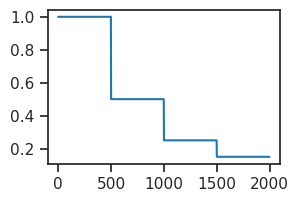

In [11]:
plot(contrasts_repeat);

In [12]:
param_grid = drifting_grating_feeder_params(
    contrast=contrasts_repeat,
    theta=[favorite_params['theta']],
    s_freq=[favorite_params['s_freq']],
)

n_frames_for_full_cycle = 500

feeder, feeder_kws = drifting_grating_feeder(
    npix=tr.model.cfg.input_sz[-1],
    param_grid=param_grid,
    device=device,
    n_frames_per_cycle=n_frames_for_full_cycle,
)

In [13]:
len(param_grid)

2000

In [14]:
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

n_runs_per_seed = 2
seq = range(n_frames_for_full_cycle * (n_runs_per_seed + 1))

print(seq)

range(0, 1500)

In [15]:
%%time

output = tr.model.xtract_ftr(
    feeder=feeder,
    seq=seq,
    return_extras=['samples'],
).stack()

CPU times: user 8.73 s, sys: 1.89 s, total: 10.6 s
Wall time: 1min 7s


In [16]:
neuron_i = order[selected_neurons[-1]]
spike_trains = tonp(output['samples'][..., neuron_i])
spike_trains = spike_trains[:, n_frames_for_full_cycle:]

shape = (len(contrasts_selected), -1, spike_trains.shape[-1])
spike_trains = spike_trains.reshape(shape)

firing_rates = spike_trains.mean(1)
firing_rates_sd = spike_trains.std(1)

spike_trains.shape, firing_rates.shape

((4, 500, 1000), (4, 1000))

In [156]:
neuron_i = order[selected_neurons[-1]]
neuron_i

318

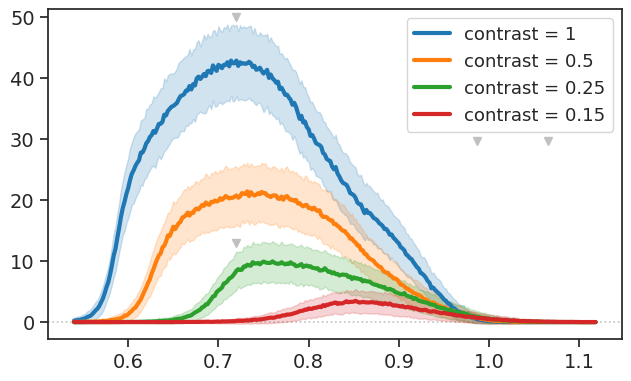

'/home/hadi/Dropbox/git/jb-progress-2025/figs/figs_2025-03/cntrst/cntrst_rates_318.pdf'

In [157]:
a = 270
b = 560
intvl = range(a, b)

xs = np.arange(a, b) / n_frames_for_full_cycle

fig, ax = create_figure(1, 1, (6.2, 3.7))

ids = [19, 9, 4, 2]
for i, cntrst in enumerate(contrasts_selected):
    # color = greys[len(greys) - i * color_spacig - 1]
    ax.plot(
        xs,
        firing_rates[i][intvl],
        color=f'C{i}',
        label=f"contrast = {cntrst:0.2g}",
        lw=3.0,
        alpha=1.0,
    )
    lower = firing_rates[i][intvl] - firing_rates_sd[i][intvl]
    higher = firing_rates[i][intvl] + firing_rates_sd[i][intvl]
    ax.fill_between(xs, lower, higher, color=f'C{i}', alpha=0.2)
ax.tick_params(axis='both', labelsize=14)
# ax.axvline(min(xs), ls='--', color='dimgrey', lw=1.4, zorder=0)
ax.axhline(0, ls=':', color='silver', lw=1.2, zorder=0)
add_legend(ax, fontsize=13)


transform = matplotlib.transforms.blended_transform_factory(
    ax.transData,  # x coordinates in data units (abs vals)
    ax.transAxes   # y coordinates in axes units (0-1)
)
selected_time_for_grating = np.argmax(firing_rates[0][intvl]) + a
# selected_time_for_grating = 362
selected_x = selected_time_for_grating / n_frames_for_full_cycle
# selected_x = (selected_time_for_grating - a) / (b - a)
for custom_y in [0.976, 0.29]: 
    ax.plot(selected_x, custom_y, color='silver', marker='v', markersize=6, transform=transform)
# ax.axvline(selected_x, ymax=0.96, ls='--', color='silver', lw=0.6, zorder=0, alpha=0.5)

custom_y = 0.6
for custom_x in [0.987, 1.065]: 
    ax.plot(custom_x, custom_y, color='silver', marker='v', markersize=6, transform=transform)

save_fig(f"cntrst_rates_{neuron_i}.pdf", save_dir=figs_dir, fig=fig, display=True)

In [158]:
selected_time_for_grating

360

In [159]:
selected_x = selected_time_for_grating / n_frames_for_full_cycle
print(f'where those triangles are put: {selected_x:0.2f}')

where those triangles are put: 0.72

## Plot the actual gratings

In [175]:
param_grid = drifting_grating_feeder_params(
    contrast=contrasts_selected,
    theta=[favorite_params['theta']],
    s_freq=[favorite_params['s_freq']],
)

n_frames_for_full_cycle = 500

feeder, feeder_kws = drifting_grating_feeder(
    npix=tr.model.cfg.input_sz[-1],
    param_grid=param_grid,
    device=device,
    n_frames_per_cycle=n_frames_for_full_cycle,
)

In [176]:
len(param_grid)

4

In [177]:
feeder_kws['flatten'] = False
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

In [178]:
frames = [feeder[t] for t in range(n_frames_for_full_cycle)]
frames = tonp(torch.cat(frames, dim=1))
frames.shape

(4, 500, 16, 16)

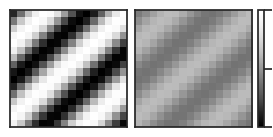

'/home/hadi/Dropbox/git/jb-progress-2025/figs/figs_2025-03/cntrst/frames.png'

In [179]:
fig, axes = create_figure(1, 2, (2.6, 1.17), 'all', 'all', layout='constrained')
fig.set_constrained_layout_pads(w_pad=0.025, h_pad=0.0, wspace=0, hspace=00)

# selected_time_for_grating = 370

axes[0].imshow(frames[0, selected_time_for_grating], cmap='Greys_r', vmin=-1, vmax=1)
im = axes[1].imshow(frames[2, selected_time_for_grating], cmap='Greys_r', vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=axes[1])
cbar.set_ticklabels([])
remove_ticks(axes, False)

save_fig(f"frames.png", save_dir=figs_dir, fig=fig, display=True, dpi=900)

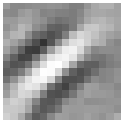

318

In [174]:
neuron_i = order[selected_neurons[-1]]
fig, _ = tr.model.show(order=[neuron_i], method='abs-max', nrows=1, dpi=30)

neuron_i

## Contrast dependent tuning curve

In [171]:
param_grid = drifting_grating_feeder_params(
    contrast_min=0.1,
    contrast_max=1.0,
    contrast_delta=0.05,
    s_freq=[favorite_params['s_freq']],
)

n_frames_for_full_cycle = 500

feeder, feeder_kws = drifting_grating_feeder(
    npix=tr.model.cfg.input_sz[-1],
    param_grid=param_grid,
    device=device,
    n_frames_per_cycle=n_frames_for_full_cycle,
)

In [172]:
len(param_grid)

703

In [173]:
%%time


trial_timepoints = range(
    n_frames_for_full_cycle,
    n_frames_for_full_cycle * 2,
)
n_trials = 100

spk_counts_all = []
for i in tqdm(range(n_trials)):
    tr.model.cfg.set_seeds(i)

    output = tr.model.xtract_ftr(
        feeder=FEEDER_CLASSES['drifting-grating'](**feeder_kws),
        seq=range(2 * n_frames_for_full_cycle),
        return_extras=['samples'],
    ).stack()

    spks = output['samples'][:, trial_timepoints]
    spk_counts_all.append(tonp(spks.sum(1)))

spk_counts_all = np.stack(spk_counts_all)
spk_counts_all.shape

100%|█████████████████████████████████████████| 100/100 [04:02<00:00,  2.43s/it]

CPU times: user 4min 2s, sys: 438 ms, total: 4min 3s
Wall time: 4min 2s


(100, 703, 512)

In [174]:
shape = (n_trials, *param_grid.param_lengths, tr.model.cfg.n_latents[0])

avg_spk_counts = spk_counts_all.reshape(shape)
avg_spk_counts = avg_spk_counts.mean(0)
avg_spk_counts.shape

(19, 1, 37, 512)

In [175]:
tuning_curves = avg_spk_counts.squeeze()
tuning_curves.shape

(19, 37, 512)

In [176]:
neuron_i = selected_neurons[-1]
tuning = tuning_curves[..., neuron_i]

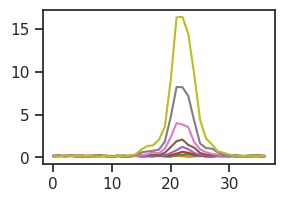

In [185]:
plot(tuning[:9].T);
# plt.yscale('log')

In [183]:
param_grid['contrast'][:6]

array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35])

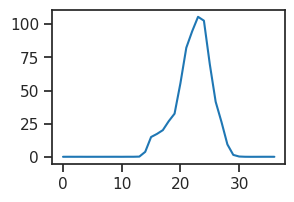

In [187]:
plot(tuning.mean(0))

## Between 0.5 and 1.0

In [8]:
favorite_params = {'s_freq': 2.0, 'theta': 48.0}

In [9]:
contrasts_selected = np.linspace(1, 0.5, 11)  # param_grid['contrast'][ids]
contrasts_selected

array([1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55, 0.5 ])

In [10]:
contrasts_repeat = np.repeat(contrasts_selected, 100)
len(contrasts_repeat)

1100

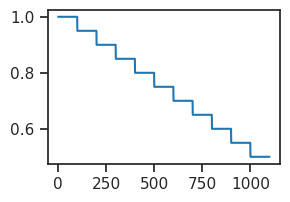

In [11]:
plot(contrasts_repeat);

In [12]:
param_grid = drifting_grating_feeder_params(
    contrast=contrasts_repeat,
    theta=[favorite_params['theta']],
    s_freq=[favorite_params['s_freq']],
)

n_frames_for_full_cycle = 500

feeder, feeder_kws = drifting_grating_feeder(
    npix=tr.model.cfg.input_sz[-1],
    param_grid=param_grid,
    device=device,
    n_frames_per_cycle=n_frames_for_full_cycle,
)

In [13]:
len(param_grid)

1100

In [14]:
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

n_runs_per_seed = 2
seq = range(n_frames_for_full_cycle * (n_runs_per_seed + 1))

print(seq)

range(0, 1500)

In [15]:
%%time

output = tr.model.xtract_ftr(
    feeder=feeder,
    seq=seq,
    return_extras=['samples'],
).stack()

CPU times: user 8.13 s, sys: 1.01 s, total: 9.14 s
Wall time: 51.4 s


In [16]:
neuron_i = order[selected_neurons[-1]]
spike_trains = tonp(output['samples'][..., neuron_i])
spike_trains = spike_trains[:, n_frames_for_full_cycle:]

shape = (len(contrasts_selected), -1, spike_trains.shape[-1])
spike_trains = spike_trains.reshape(shape)

firing_rates = spike_trains.mean(1)
firing_rates_sd = spike_trains.std(1)

spike_trains.shape, firing_rates.shape

((11, 100, 1000), (11, 1000))

In [22]:
coolwarm = sns.color_palette('coolwarm', n_colors=len(contrasts_selected))
coolwarm

[(0.32860444731764704, 0.43971182997647057, 0.8695872625411765),
 (0.4358148063058824, 0.5707073031529412, 0.951717381282353),
 (0.5543118699137254, 0.6900970112156862, 0.9955155482352941),
 (0.6672529243333334, 0.7791764569999999, 0.992959213),
 (0.7727059486039215, 0.8389782172392156, 0.9493187599137255),
 (0.8674276350862745, 0.864376599772549, 0.8626024620196079),
 (0.9383263563333333, 0.8089165520313726, 0.741161515027451),
 (0.968203399, 0.7208441, 0.6122929913333334),
 (0.9566532109764706, 0.598033822717647, 0.4773022923529412),
 (0.9057834780117647, 0.4551856921647059, 0.35533588384705883),
 (0.8204010983882353, 0.2867649126352941, 0.2451595198)]

<Axes: >

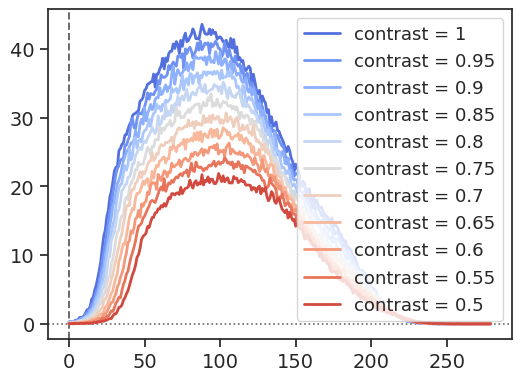

In [25]:
a = 270
b = 550
intvl = range(a, b)

fig, ax = create_figure(1, 1, (5.1, 3.7))

ids = [19, 9, 4, 2]
for i, cntrst in enumerate(contrasts_selected):
    color = coolwarm[i]
    ax.plot(
        range(b - a),
        firing_rates[i][intvl],
        color=color,
        label=f"contrast = {cntrst:0.2g}",
        lw=2.0,
        alpha=1.0,
    )
    # lower = firing_rates[i][intvl] - firing_rates_sd[i][intvl]
    # higher = firing_rates[i][intvl] + firing_rates_sd[i][intvl]
    # ax.fill_between(range(b - a), lower, higher, color=f'C{i}', alpha=0.2)
ax.tick_params(axis='both', labelsize=14)
ax.axvline(0, ls='--', color='dimgrey', lw=1.4, zorder=0)
ax.axhline(0, ls=':', color='dimgrey', lw=1.2, zorder=0)
add_legend(ax, fontsize=13)

# save_fig(f"cntrst_rates_{neuron_i}.pdf", save_dir=figs_dir, fig=fig, display=True)
# plt.close()

## First harmonic

Carandini 1997 analysis

In [26]:
neuron_i = order[selected_neurons[-1]]
spike_trains = tonp(output['samples'][..., neuron_i])
spike_trains = spike_trains[:, n_frames_for_full_cycle:]
spike_trains.shape

(1100, 1000)

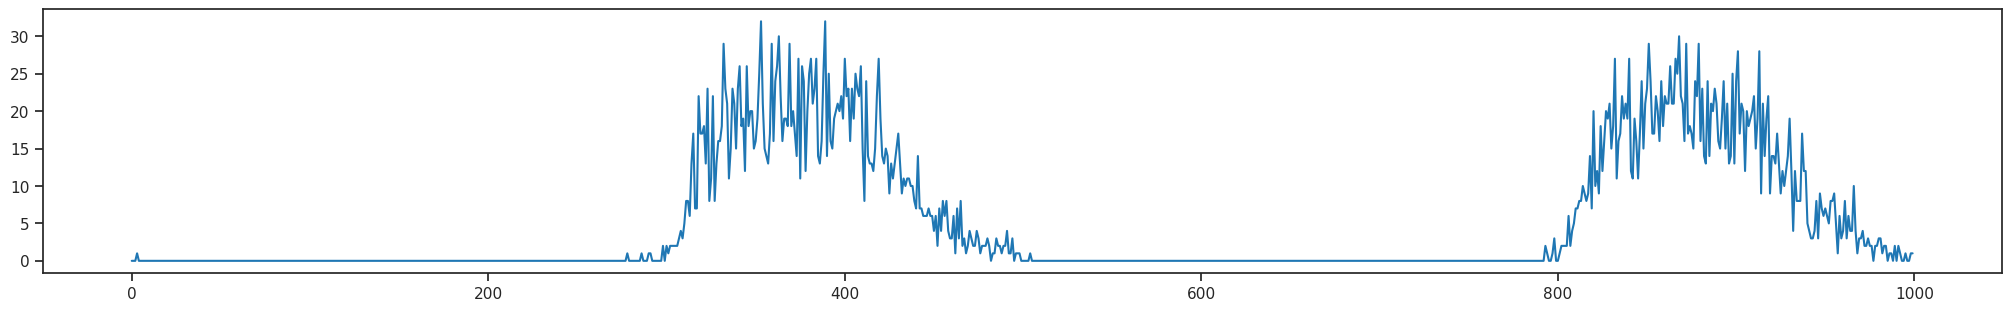

In [28]:
fig, ax = create_figure(1, 1, (20, 3))
plt.plot(spike_trains[-1]);

In [29]:
def do_it(spike_train: np.ndarray, cycle_length: int, bin_size_in_seconds: float = 1.0):
    t_freq = 1 / cycle_length
    total_time = len(spike_train)
    ts = np.arange(total_time)
    
    first_harmonic = np.sum(spike_train * np.exp(-2j * np.pi * t_freq * ts)) / total_time
    
    amplitude = 2 * np.abs(first_harmonic)  # Multiply by 2 for one-sided spectrum
    phase_radians = np.angle(first_harmonic)
    phase_degrees = np.degrees(phase_radians)
    
    amplitude_spikes_per_sec = amplitude / bin_size_in_seconds

    return amplitude_spikes_per_sec, phase_degrees

In [31]:
amplitude_spikes_per_sec, phase_degrees = do_it(
    spike_train=spike_trains[-1],
    cycle_length=n_frames_for_full_cycle,
    bin_size_in_seconds=0.2,
)

print(f"Response amplitude: {amplitude_spikes_per_sec:.2f} spikes/sec")
print(f"Response phase: {phase_degrees:.2f} degrees")

Response amplitude: 43.88 spikes/sec

Response phase: 86.54 degrees

In [32]:
amplitudes, phases = [], []
for x in spike_trains:
    amplitude_spikes_per_sec, phase_degrees = do_it(
        spike_train=x,
        cycle_length=n_frames_for_full_cycle,
        bin_size_in_seconds=0.4,
    )
    amplitudes.append(amplitude_spikes_per_sec)
    phases.append(phase_degrees)

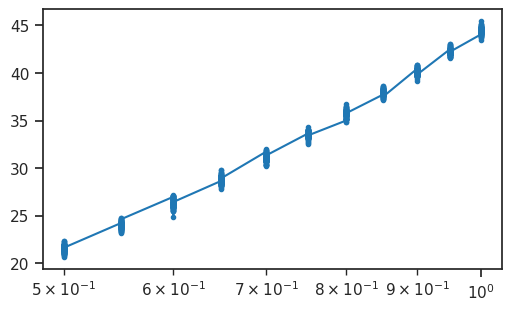

In [33]:
fig, ax = create_figure(1, 1, (5, 3))
ax.plot(param_grid.param_dict['contrast'], amplitudes, marker='.')
ax.set(xscale='log')
plt.show()

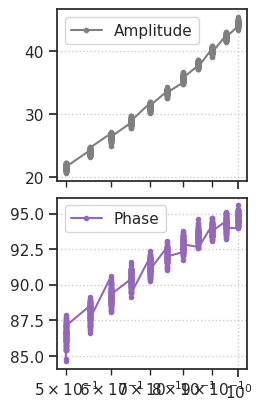

In [34]:
fig, axes = create_figure(2, 1, (2.5, 4), sharex='all')
axes[0].plot(param_grid.param_dict['contrast'][10:], amplitudes[10:], label='Amplitude', color='C7', marker='.')
axes[1].plot(param_grid.param_dict['contrast'][10:], phases[10:], label='Phase', color='C4', marker='.')
axes[1].set(xscale='log')
add_legend(axes)
add_grid(axes)
plt.show()